In [2]:
import os
import numpy as np
import nibabel as nib
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision.utils import make_grid
import torchvision.transforms as transforms
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt
from glob import glob

In [3]:
BRATS_PATH = "/kaggle/input/brats2024-small-dataset/BraTS2024_small_dataset"
PMC_PATH = "/kaggle/input/pmc-tiny-dataset-t1-t2/pmc_dataset"
SAVE_PATH = "/kaggle/working/preprocessed_cgan"
os.makedirs(SAVE_PATH, exist_ok=True)

MODALITIES = {
    "t1n": "t1n.nii",
    "t1c": "t1c.nii",
    "t2w": "t2w.nii",
    "t2f": "t2f.nii"
}

IMG_SIZE = 256
SLICES_PER_PATIENT = 20


In [4]:
def preprocess_slice(img, size=IMG_SIZE):
    img = np.nan_to_num(img)
    img = (img - np.min(img)) / (np.max(img) - np.min(img) + 1e-8)
    return cv2.resize(img, (size, size), interpolation=cv2.INTER_AREA)

patients = sorted(glob(os.path.join(BRATS_PATH, "*")))
print("Found", len(patients), "patients")

for patient in tqdm(patients[:50]):  # reduce if needed
    pid = os.path.basename(patient)
    volumes = {}

    for mod, suffix in MODALITIES.items():
        path = glob(os.path.join(patient, f"*{suffix}"))[0]
        volumes[mod] = nib.load(path).get_fdata()

    center = volumes["t1n"].shape[2] // 2
    z_range = range(center - SLICES_PER_PATIENT//2, center + SLICES_PER_PATIENT//2)

    for z in z_range:
        for mod in MODALITIES:
            img = preprocess_slice(volumes[mod][:, :, z])
            np.save(os.path.join(SAVE_PATH, f"{pid}_z{z}_{mod}.npy"), img)

Found 200 patients


100%|██████████| 50/50 [00:20<00:00,  2.50it/s]


In [5]:
class BraTSCGANDataset(Dataset):
    def __init__(self, path, t1_mods, t2_mods):
        self.path = path
        self.t1_mods = t1_mods
        self.t2_mods = t2_mods

        self.ids = sorted([
            f.replace(f"_{t1_mods}.npy", "")
            for f in os.listdir(path) if f.endswith(f"_{t1_mods}.npy")
        ])

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        base = self.ids[idx]
        t1_images = [np.load(os.path.join(self.path, f"{base}_{self.t1_mods}.npy"))]
        t2_images = [np.load(os.path.join(self.path, f"{base}_{self.t2_mods}.npy"))]

        t1 = torch.tensor(t1_images, dtype=torch.float32)
        t2 = torch.tensor(t2_images, dtype=torch.float32)
        return t1, t2


In [6]:
class PMCDataset(Dataset):
    def __init__(self, root, transform):
        self.transform = transform
        self.t1_dir = os.path.join(root, 'T1')
        self.t2_dir = os.path.join(root, 'T2')
        self.t1_images = sorted(os.listdir(self.t1_dir))
        self.t2_images = sorted(os.listdir(self.t2_dir))

    def __len__(self):
        return max(len(self.t1_images), len(self.t2_images))

    def __getitem__(self, index):
        t1_path = os.path.join(self.t1_dir, self.t1_images[index])
        t2_path = os.path.join(self.t2_dir, self.t2_images[index])

        t1_images = Image.open(t1_path).convert("L")
        t2_images = Image.open(t2_path).convert("L")
        
        if self.transform:
            t1_images = self.transform(t1_images)
            t2_images = self.transform(t2_images)

        return t1_images, t2_images

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: (x - x.min()) / (x.max() - x.min() + 1e-8))
])

/tmp/ipykernel_31/1524843857.py:20: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:278.)
  t1 = torch.tensor(t1_images, dtype=torch.float32)


Inputs: torch.Size([4, 1, 256, 256]) | Targets: torch.Size([4, 1, 256, 256])


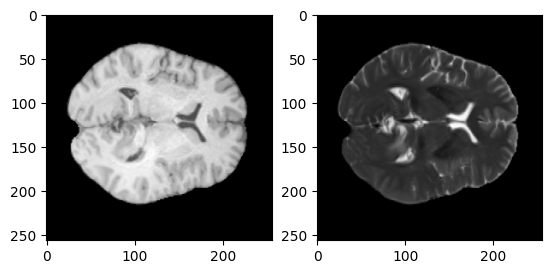

Inputs: torch.Size([4, 1, 256, 256]) | Targets: torch.Size([4, 1, 256, 256])


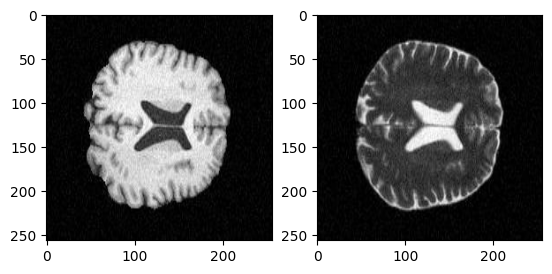

In [7]:
t1_mods = "t1n"
t2_mods = "t2w"

brats_dataset = BraTSCGANDataset(SAVE_PATH, t1_mods, t2_mods)
brats_dataloader = DataLoader(brats_dataset, batch_size=4, shuffle=True)
pmc_dataset = PMCDataset(PMC_PATH, transform)
pmc_dataloader = DataLoader(pmc_dataset, batch_size=4, shuffle=True)

t1, t2 = next(iter(brats_dataloader))
print("Inputs:", t1.shape, "| Targets:", t2.shape)
t1 = t1[0].numpy().transpose(1, 2, 0)
t2 = t2[0].numpy().transpose(1, 2, 0)
plt.subplot(1, 2, 1)
plt.imshow(t1, cmap='gray')
plt.subplot(1, 2, 2)
plt.imshow(t2, cmap='gray')
plt.show()

t1, t2 = next(iter(pmc_dataloader))
print("Inputs:", t1.shape, "| Targets:", t2.shape)
t1 = t1[0].numpy().transpose(1, 2, 0)
t2 = t2[0].numpy().transpose(1, 2, 0)
plt.subplot(1, 2, 1)
plt.imshow(t1, cmap='gray')
plt.subplot(1, 2, 2)
plt.imshow(t2, cmap='gray')
plt.show()

In [ ]:
def visualize_samples(generator, dataloader, label):
    generator.eval()
    x, y = next(iter(dataloader))
    x = x.to(device)
    with torch.no_grad():
        preds = generator(x, label).cpu().numpy()
    x = x.cpu().numpy()
    y = y.cpu().numpy()

    plt.figure(figsize=(15, 8))
    for i in range(3):
        plt.subplot(3, 5, i*5 + 1)
        plt.imshow(x[i][0], cmap="gray")
        plt.title("Input")

        plt.subplot(3, 5, i*5 + 2)
        plt.imshow(y[i][0], cmap="gray")
        plt.title("Target")

        plt.subplot(3, 5, i*5 + 3)
        plt.imshow(preds[i][0], cmap="gray")
        plt.title("Pred")

    plt.tight_layout()
    plt.show()

visualize_samples(generator, pmc_dataloader, 0)
visualize_samples(generator, brats_dataloader, 1)

In [8]:
class Generator(nn.Module):
    """
    A U-Net style generator with 8 down-samplings and 8 up-samplings.
    This version produces the SAME spatial size as the input (means input and output remain as 256x256) 
    The final layer of the generator does not make the image bigger anymore.
    """
    def __init__(self, input_channels=1, output_channels=1):
        super(Generator, self).__init__()

        # Encoder layers
        self.e1 = self._conv_block(input_channels + 1, 64, batch_norm=False)  # 256 -> 128 (+1 for condition)
        self.e2 = self._conv_block(64, 128)                               # 128 -> 64
        self.e3 = self._conv_block(128, 256)                              # 64 -> 32
        self.e4 = self._conv_block(256, 512)                              # 32 -> 16
        self.e5 = self._conv_block(512, 512)                              # 16 -> 8
        self.e6 = self._conv_block(512, 512)                              # 8 -> 4
        self.e7 = self._conv_block(512, 512)                              # 4 -> 2
        # No batch norm on last encoder
        self.e8 = self._conv_block(512, 512, batch_norm=False)            # 2 -> 1

        # Decoder layers 
        # Each deconv_block uses stride=2 => doubles spatial dimension
        self.d1 = self._deconv_block(512, 512, dropout=True)              # 1 -> 2
        self.d2 = self._deconv_block(512 + 512, 512, dropout=True)        # 2 -> 4
        self.d3 = self._deconv_block(512 + 512, 512, dropout=True)        # 4 -> 8
        self.d4 = self._deconv_block(512 + 512, 512)                      # 8 -> 16
        self.d5 = self._deconv_block(512 + 512, 512)                      # 16 -> 32
        self.d6 = self._deconv_block(512 + 256, 256)                      # 32 -> 64
        self.d7 = self._deconv_block(256 + 128, 128)                      # 64 -> 128
        self.d8 = self._deconv_block(128 + 64, 64)                        # 128 -> 256

        # Output
        # A 3×3 conv that preserves 256×256 (stride=1),
        # mapping from 64 channels -> output_channels
        self.output = nn.Sequential(
            nn.Conv2d(64, output_channels, kernel_size=3, stride=1, padding=1),
            nn.Tanh()
        )

        # Weight initialisation
        init_weights(self, init_type='normal', gain=0.02)

    # changed conv block to use InstanceNorm2d instead of BatchNorm2d
    # https://www.jmis.org/archive/view_article?pid=jmis-11-2-157
    def _conv_block(self, in_channels, out_channels,
                    kernel_size=4, stride=2, padding=1, batch_norm=True):
        """
        Downsampling block: Conv2d + (Optionally) InstanceNorm + LeakyReLU.
        """
        layers = []
        layers.append(nn.Conv2d(in_channels, out_channels,
                                kernel_size, stride, padding,
                                bias=not batch_norm))
        if batch_norm:
            layers.append(nn.InstanceNorm2d(out_channels))
        layers.append(nn.LeakyReLU(0.2, inplace=True))
        return nn.Sequential(*layers)

    # same thing, using InstanceNorm2d
    def _deconv_block(self, in_channels, out_channels,
                      kernel_size=4, stride=2, padding=1, dropout=False):
        """
        Upsampling block: ConvTranspose2d + InstanceNorm + ReLU (+ optional Dropout).
        """
        layers = []
        layers.append(nn.ConvTranspose2d(in_channels, out_channels,
                                         kernel_size, stride, padding,
                                         bias=False))
        layers.append(nn.InstanceNorm2d(out_channels))
        layers.append(nn.ReLU(True))
        if dropout:
            layers.append(nn.Dropout(0.5))
        return nn.Sequential(*layers)

    def forward(self, x, label=0):
        label = torch.ones_like(x[:, :1, :, :])*label
        # Condition: binary flag for non-tumor/tumor images
        e1 = self.e1(torch.cat([x, label], dim=1))
        e2 = self.e2(e1)
        e3 = self.e3(e2)
        e4 = self.e4(e3)
        e5 = self.e5(e4)
        e6 = self.e6(e5)
        e7 = self.e7(e6)
        e8 = self.e8(e7)

        d1 = self.d1(e8)
        d2 = self.d2(torch.cat([d1, e7], 1))
        d3 = self.d3(torch.cat([d2, e6], 1))
        d4 = self.d4(torch.cat([d3, e5], 1))
        d5 = self.d5(torch.cat([d4, e4], 1))
        d6 = self.d6(torch.cat([d5, e3], 1))
        d7 = self.d7(torch.cat([d6, e2], 1))
        d8 = self.d8(torch.cat([d7, e1], 1))

        return self.output(d8)


In [9]:
class Discriminator(nn.Module):
    """
    Uses BCEWithLogitsLoss (so no Sigmoid at the end).
    """
    def __init__(self, in_channels=1, out_channels=1):
        super(Discriminator, self).__init__()
        
        # input + 2 conditions (target image + tumor/non-tumor cond)
        self.model = nn.Sequential(
            self.disc_block(in_channels * 2 + 1, 64, batch_norm=False),
            self.disc_block(64, 128),
            self.disc_block(128, 256),
            self.disc_block(256, 512, stride=1),
            nn.Conv2d(512, out_channels, kernel_size=4, stride=1, padding=1)
        )

        # Weight initialisation
        init_weights(self, init_type='normal', gain=0.02)
    
    def disc_block(self, in_channels, out_channels, kernel_size=4, stride=2, padding=1, batch_norm=True):
        layers = [nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, bias=not batch_norm)]
        if batch_norm:
            layers.append(nn.InstanceNorm2d(out_channels))
        layers.append(nn.LeakyReLU(0.2, inplace=True))
        return nn.Sequential(*layers)

    def forward(self, x, y, label=0):
        label = torch.ones_like(x[:, :1, :, :])*label
        # Conditions:
        # 1. y, the target translation image
        # 2. label, a binary flag 0/1 for non-tumor/tumor respectively
        # Concatenation along channel dim
        inp = torch.cat([x, y, label], dim=1)
        return self.model(inp)
        

In [10]:
def init_weights(net, init_type='normal', gain=0.02):
    """
    Apply the recommended weight initialisation for GANs.
    """
    def init_func(m):
        classname = m.__class__.__name__
        if hasattr(m, 'weight') and ('Conv' in classname or 'Linear' in classname):
            if init_type == 'normal':
                nn.init.normal_(m.weight.data, 0.0, gain)
            elif init_type == 'xavier':
                nn.init.xavier_normal_(m.weight.data, gain=gain)
            elif init_type == 'kaiming':
                nn.init.kaiming_normal_(m.weight.data, a=0, mode='fan_in')
            else:
                raise NotImplementedError(f"initialisation method [{init_type}] is not implemented")
            if hasattr(m, 'bias') and m.bias is not None:
                nn.init.constant_(m.bias.data, 0.0)
        elif 'BatchNorm2d' in classname or 'InstanceNorm2d' in classname:
            if hasattr(m, 'weight') and m.weight is not None:
                nn.init.normal_(m.weight.data, 1.0, gain)
            if hasattr(m, 'bias') and m.bias is not None:
                nn.init.constant_(m.bias.data, 0.0)
    net.apply(init_func)

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Instantiate the models
generator = Generator().to(device)
discriminator = Discriminator().to(device)

# Loss functions
gan_loss = nn.BCEWithLogitsLoss()
l1_loss = nn.L1Loss()

# Optimisers
optimizer_G = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

# Hyperparameters
lambda_l1 = 100
epochs = 100
real_label_val = 0.95
fake_label_val = 0.0

# Track losses
g_losses = []
d_losses = []

for epoch in range(epochs):
    for i, dataloader in enumerate([pmc_dataloader, brats_dataloader]):
        for j, data in enumerate(dataloader):
            t1 = data[0].to(device)
            t2 = data[1].to(device)
    
            fake_t1 = generator(t2, i)
            pred_fake = discriminator(t2, fake_t1, i)
            patch_size = pred_fake.shape[2:]
    
            real_label = torch.full((t2.size(0), 1, *patch_size), real_label_val, dtype=torch.float, device=device)
            fake_label = torch.full((t2.size(0), 1, *patch_size), fake_label_val, dtype=torch.float, device=device)
    
            # ======== Train Generator ========
            optimizer_G.zero_grad()
            pred_fake = discriminator(t2, fake_t1, i)
            loss_g_adv = gan_loss(pred_fake, real_label)
            loss_g_l1 = l1_loss(fake_t1, t1) * lambda_l1
            loss_g = loss_g_adv + loss_g_l1
            loss_g.backward()
            optimizer_G.step()
    
            # ======== Train Discriminator ========
            optimizer_D.zero_grad()
            pred_real = discriminator(t2, t1, i)
            loss_d_real = gan_loss(pred_real, real_label)
            pred_fake = discriminator(t2, fake_t1.detach(), i)
            loss_d_fake = gan_loss(pred_fake, fake_label)
            loss_d = 0.5 * (loss_d_real + loss_d_fake)
            loss_d.backward()
            optimizer_D.step()
    
            # Save losses
            g_losses.append(loss_g.item())
            d_losses.append(loss_d.item())
    
            # Print progress
            if j % len(dataloader) == 0:
                print(f"(Dataset {i+1}) Epoch [{epoch+1}/{epochs}] Step [{j}/{len(dataloader)}] "
                      f"G_Loss: {loss_g.item():.4f} D_Loss: {loss_d.item():.4f}")

torch.save(generator.state_dict(), 'cgan_unet100generator.pth')
torch.save(discriminator.state_dict(), 'cgan_unet100discriminator.pth')

(Dataset 1) Epoch [1/100] Step [0/165] G_Loss: 47.9683 D_Loss: 0.8295
(Dataset 2) Epoch [1/100] Step [0/250] G_Loss: 7.9519 D_Loss: 0.7299
(Dataset 1) Epoch [2/100] Step [0/165] G_Loss: 6.9916 D_Loss: 0.7126
(Dataset 2) Epoch [2/100] Step [0/250] G_Loss: 7.8027 D_Loss: 0.6652
(Dataset 1) Epoch [3/100] Step [0/165] G_Loss: 4.5651 D_Loss: 0.7874
(Dataset 2) Epoch [3/100] Step [0/250] G_Loss: 4.6853 D_Loss: 0.7121
(Dataset 1) Epoch [4/100] Step [0/165] G_Loss: 4.1491 D_Loss: 0.7287
(Dataset 2) Epoch [4/100] Step [0/250] G_Loss: 6.0054 D_Loss: 0.7045
(Dataset 1) Epoch [5/100] Step [0/165] G_Loss: 4.6289 D_Loss: 0.7809
(Dataset 2) Epoch [5/100] Step [0/250] G_Loss: 3.9620 D_Loss: 0.7344
(Dataset 1) Epoch [6/100] Step [0/165] G_Loss: 4.0891 D_Loss: 0.7814
(Dataset 2) Epoch [6/100] Step [0/250] G_Loss: 5.1488 D_Loss: 0.6701
(Dataset 1) Epoch [7/100] Step [0/165] G_Loss: 3.8485 D_Loss: 0.8687
(Dataset 2) Epoch [7/100] Step [0/250] G_Loss: 5.1671 D_Loss: 0.6060
(Dataset 1) Epoch [8/100] Step [0

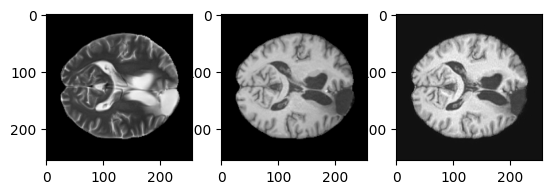

In [15]:
generator.eval()

dataset_iter = iter(brats_dataloader)
data = next(dataset_iter)

t1 = data[0].to(device)
t2 = data[1].to(device)

t1_fake = generator(t2, 0)
t1_fake = t1_fake[0].cpu().detach().numpy().transpose(1, 2, 0)

t1 = t1[0].cpu().numpy().transpose(1, 2, 0)
t2 = t2[0].cpu().numpy().transpose(1, 2, 0)

plt.subplot(1, 3, 1)
plt.imshow(t2, cmap='gray')
plt.subplot(1, 3, 2)
plt.imshow(t1, cmap='gray')
plt.subplot(1, 3, 3)
plt.imshow(t1_fake, cmap='gray')
plt.show()


In [14]:
from skimage.metrics import structural_similarity, peak_signal_noise_ratio

def evaluate(generator, dataloader, label):
    generator.eval()
    ssim_total, psnr_total = [], []
    with torch.no_grad():
        for t1, t2 in dataloader:
            t2 = t2.to(device)
            preds = generator(t2, label).cpu().numpy()
            targets = t1.numpy()

            preds = np.clip(preds, 0, 1)
            targets = np.clip(targets, 0, 1)

            for i in range(preds.shape[0]):
                psnr_total.append(peak_signal_noise_ratio(targets[i][0], preds[i][0], data_range=1.0))
                ssim_total.append(structural_similarity(targets[i][0], preds[i][0], data_range=1.0))

    return np.mean(ssim_total), np.mean(psnr_total)

# Run this after training
ssim_val, psnr_val = evaluate(generator, pmc_dataloader, 0)
print(f"✅ SSIM (T2 -> T1 (Non-Tumor)): {ssim_val:.4f}")
print(f"✅ PSNR (T2 -> T1 (Non-Tumor)): {psnr_val:.4f}")
ssim_val, psnr_val = evaluate(generator, brats_dataloader, 1)
print(f"✅ SSIM (T2 -> T1 (Tumor)): {ssim_val:.4f}")
print(f"✅ PSNR (T2 -> T1 (Tumor)): {psnr_val:.4f}")

✅ SSIM (T2 -> T1 (Non-Tumor)): 0.9319
✅ PSNR (T2 -> T1 (Non-Tumor)): 31.5691
✅ SSIM (T2 -> T1 (Tumor)): 0.9712
✅ PSNR (T2 -> T1 (Tumor)): 36.4556
